---
tags:
  - sparse-ad
  - mixed-dimension
---

# Embedded 1D Fibers

In [ ]:
# [collapse: code] Colab Setup (Install Dependencies)

# Only run this if we are in Google Colab
if 'google.colab' in str(get_ipython()):
    print("Installing dependencies using uv...")
    # Install uv if not available
    !pip install -q uv
    # Install system dependencies
    !apt-get install -qq gmsh
    # Use uv to install Python dependencies
    !uv pip install --system matplotlib meshio
    !uv pip install --system "git+https://github.com/smec-ethz/tatva-docs.git"
    print("Installation complete!")
else:
    import pyvista as pv


we consider a fiber-reinforced composite in which stiff 1D fibers are embedded in a soft 2D soft material. A central difficulty in such problems is that the fiber geometry typically does not align with the bulk mesh. The fibers may intersect bulk elements at arbitrary positions and orientations. In this example, we use an embedded-element approach formulated entirely at the level of the total potential energy.

In [1]:
import jax


from typing import NamedTuple

import jax.numpy as jnp
from jax import Array
from jax_autovmap import autovmap

from tatva import Mesh, Operator, compound, element, lifter, sparse

jax.config.update("jax_enable_x64", True)  # use double-precision

In [2]:
# [collapse: code] Mesh Generation

import os

import gmsh
import matplotlib.pyplot as plt
import meshio
import numpy as np


def generate_plate_mesh(
    Lx: float, Ly: float, mesh_size: float, work_dir: str = "."
) -> Mesh:
    """
    Generates a 2D unstructured triangular mesh for a rectangular plate.

    Args:
        Lx (float): Length of the plate in the x-direction.
        Ly (float): Length of the plate in the y-direction.
        mesh_size (float): Target mesh size for the mesh generation.
        work_dir (str): Directory to store temporary mesh files.

    Returns:
        Mesh: The generated plate mesh.
    """
    if not os.path.exists(work_dir):
        os.makedirs(work_dir)

    filename = os.path.join(work_dir, "plate_2d.msh")

    gmsh.initialize()
    gmsh.model.add("plate")

    p1 = gmsh.model.geo.addPoint(0, 0, 0, mesh_size)
    p2 = gmsh.model.geo.addPoint(Lx, 0, 0, mesh_size)
    p3 = gmsh.model.geo.addPoint(Lx, Ly, 0, mesh_size)
    p4 = gmsh.model.geo.addPoint(0, Ly, 0, mesh_size)

    l1 = gmsh.model.geo.addLine(p1, p2)
    l2 = gmsh.model.geo.addLine(p2, p3)
    l3 = gmsh.model.geo.addLine(p3, p4)
    l4 = gmsh.model.geo.addLine(p4, p1)

    loop = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
    _ = gmsh.model.geo.addPlaneSurface([loop])

    # 2. Mesh Generation
    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(2)
    gmsh.write(filename)
    gmsh.finalize()

    # 3. Read back with meshio
    m = meshio.read(filename)
    if os.path.exists(filename):
        os.remove(filename)

    points = m.points[:, :2]  # Drop z-coordinate for 2D
    triangles = m.cells_dict["triangle"]

    return Mesh(points, triangles)


def generate_honeycomb_mesh(
    start_x: float,
    start_y: float,
    n_x: int,
    n_y: int,
    side_length: float,
    segments_per_side: int = 1,
) -> Mesh:
    """
    Generates a 2D honeycomb mesh (hexagonal grid) with specified parameters.
    Each hexagon side can be subdivided into smaller segments.

    Args:
        start_x (float): Starting x-coordinate of the honeycomb grid.
        start_y (float): Starting y-coordinate of the honeycomb grid.
        n_x (int): Number of hexagons along the x-direction.
        n_y (int): Number of hexagons along the y-direction.
        side_length (float): Length of each side of the hexagon.
        segments_per_side (int): Number of subdivisions per hexagon side.

    Returns:
        Mesh: The generated honeycomb mesh.
    """

    dx = np.sqrt(3) * side_length
    dy = 1.5 * side_length
    row_offset = (np.sqrt(3) * side_length) / 2.0

    node_map = {}
    coords_list = []
    lines_list = []
    edge_set = set()

    def get_or_create_node(x, y):
        key = (round(x, 6), round(y, 6))
        if key not in node_map:
            idx = len(coords_list)
            coords_list.append([x, y])
            node_map[key] = idx
            return idx
        return node_map[key]

    angles = np.deg2rad([30, 90, 150, 210, 270, 330])

    for row in range(n_y):
        cols_in_this_row = n_x if (row % 2 == 0) else (n_x - 1)
        current_offset = 0.0 if (row % 2 == 0) else row_offset

        for col in range(cols_in_this_row):
            cx = start_x + (col * dx) + current_offset
            cy = start_y + (row * dy)

            corners = []
            for theta in angles:
                vx = cx + side_length * np.cos(theta)
                vy = cy + side_length * np.sin(theta)
                corners.append((vx, vy))

            for k in range(6):
                # Start and End coordinates of the current side
                start_pt = np.array(corners[k])
                end_pt = np.array(corners[(k + 1) % 6])

                # Get the Node Index for the start of the side
                current_node_idx = get_or_create_node(start_pt[0], start_pt[1])

                # Vector along the side
                side_vector = end_pt - start_pt

                for i in range(1, segments_per_side + 1):
                    # Calculate fraction of distance (e.g., 1/3, 2/3, 3/3)
                    t = i / segments_per_side

                    # Calculate next coordinate
                    next_pt = start_pt + t * side_vector

                    # Get index for this new point
                    next_node_idx = get_or_create_node(next_pt[0], next_pt[1])

                    # Create the small segment
                    edge_key = tuple(sorted((current_node_idx, next_node_idx)))
                    if edge_key not in edge_set:
                        edge_set.add(edge_key)
                        lines_list.append([current_node_idx, next_node_idx])

                    # Move forward
                    current_node_idx = next_node_idx

    return Mesh(np.array(coords_list), np.array(lines_list))

In [3]:
# [output: hide] 

Lx, Ly = 2.0, 2.0
plate_mesh = generate_plate_mesh(Lx=Lx, Ly=Ly, mesh_size=0.04)
n_nodes = plate_mesh.coords.shape[0]
n_dofs_per_node = 2  
n_dofs = n_nodes * n_dofs_per_node

fiber_mesh = generate_honeycomb_mesh(
    start_x=0.6, start_y=0.7, n_x=3, n_y=3, side_length=0.2, segments_per_side=3
)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000292872s, CPU 0.000414s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0697915s, CPU 0.068195s)
Info    : 3013 nodes 6028 elements
Info    : Writing './plate_2d.msh'...
Info    : Done writing './plate_2d.msh'



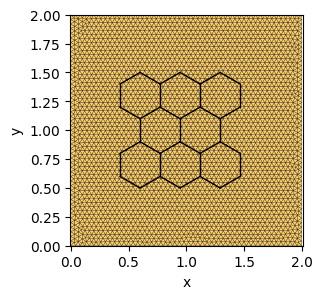

In [4]:
# [Collapse: code] Visualize Meshes

plt.figure(figsize=(3, 3))
ax = plt.gca()

ax.tripcolor(
    plate_mesh.coords[:, 0],
    plate_mesh.coords[:, 1],
    plate_mesh.elements,
    facecolors=jnp.ones(plate_mesh.elements.shape[0]),
    edgecolors="k",
    cmap="managua",
    lw=0.2,
)

for i, el in enumerate(fiber_mesh.elements):
    p0 = fiber_mesh.coords[el[0]]
    p1 = fiber_mesh.coords[el[1]]
    ax.plot(
        [p0[0], p1[0]],
        [p0[1], p1[1]],
        "k-",
        lw=1,
    )

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
ax.margins(0.0, 0.0)
plt.show()

We define two operator one for the bulk material which consists of `Tri3` elements and one for fibers which are 1D elements emebeded in 2D space. For this we define a new elemenr `Line2in3D` which takes the displacements defined in 2D or 3D space and then project this displacement along its tangent vector.

In [6]:
# [Collapse: code] Define Custom Line Element in 3D for Fiber Representation

class SpringElement(element.Line2):
    """
    A 2-node linear element embedded in 3D space.
    Reference domain: [-1, 1]
    """

    def shape_function(self, xi: Array) -> Array:
        return jnp.array([0.5 * (1.0 - xi[0]), 0.5 * (1.0 + xi[0])])

    def shape_function_derivative(self, xi: Array) -> Array:
        return jnp.array([[-0.5, 0.5]])

    def get_jacobian(self, xi: Array, nodal_coords: Array) -> tuple[Array, Array]:
        """
        nodal_coords: (2, 3) -> Two nodes in 3D space
        """
        dN_dxi = self.shape_function_derivative(xi)

        J_vec = dN_dxi @ nodal_coords  # (1, 2) @ (2, 3) -> (1, 3)

        detJ = jnp.linalg.norm(J_vec)
        return J_vec, detJ

    def gradient(self, xi: Array, nodal_values: Array, nodal_coords: Array) -> Array:
        """
        Returns the 3D Gradient vector.
        """
        J_vec, detJ = self.get_jacobian(xi, nodal_coords)
        dN_dxi = self.shape_function_derivative(xi)
        du_dxi = dN_dxi @ nodal_values

        du_ds = du_dxi / detJ

        tangent = J_vec / detJ
        grad_u_3d = jnp.vdot(du_ds, tangent)

        return grad_u_3d

In [7]:
op_plate = Operator(plate_mesh, element.Tri3())
op_line = Operator(fiber_mesh, SpringElement())

We now find the bulk material elements that contain the nodes of each fiber and then map these nodes to the quadrature points of that element. We use `Operator.make_interpolater` to do this.

In [8]:
interpolater = op_plate.make_interpolate(fiber_mesh.coords)

## Defining the energy for the bulk material

In [9]:
@autovmap(grad_u=2)
def compute_deformation_gradient(grad_u):
    I = jnp.eye(2)
    F = I + grad_u
    return F


@autovmap(F=2, mu=0, lmbda=0)
def strain_energy(F, mu, lmbda):
    C = F.T @ F
    I1 = jnp.trace(C)
    J = jnp.linalg.det(F)
    # return mu / 2 * (I1 - 3) - lmbda * jnp.log(J) + (lmbda / 2) * (jnp.log(J)) ** 2
    return 0.5 * mu * (I1 - 2 - 2 * jnp.log(J)) + (lmbda / 2) * (jnp.log(J)) ** 2


@jax.jit
def total_material_energy(u: Array) -> Array:
    u_grad = op_plate.grad(u)
    F = compute_deformation_gradient(u_grad)
    energy_density = strain_energy(F, mat.mu, mat.lmbda)
    return op_plate.integrate(energy_density)


@autovmap(grad_u=0)
def compute_fiber_energy(grad_u):
    return 0.5 * E_fiber * jnp.dot(grad_u, grad_u) * Area_fiber

In [10]:
class Material(NamedTuple):
    """Material properties for the elasticity operator."""

    mu: float  # Diffusion coefficient
    lmbda: float  # Diffusion coefficient


mat = Material(mu=1, lmbda=10.0)

E = mat.mu * (3 * mat.lmbda + 2 * mat.mu) / (mat.lmbda + mat.mu)
print(f"Effective Young's Modulus of the Plate: E = {E:.2f}")

Effective Young's Modulus of the Plate: E = 2.91


## Defining energy for the fiber network

We now compute the energy of the fibe network which defined as 

$$
\psi_\text{fiber}(\varepsilon_\text{fiber}) = \frac{1}{2}E_\text{fiber}A_\text{fiber} \varepsilon_\text{fiber}^2
$$

In [11]:
E_fiber = 100 * E  # Much stiffer than bulk
Area_fiber = 0.01

In [12]:
p0 = fiber_mesh.coords[fiber_mesh.elements[:, 0]]
p1 = fiber_mesh.coords[fiber_mesh.elements[:, 1]]
vecs = p1 - p0
lengths = np.linalg.norm(vecs, axis=1)
tangents = vecs / lengths[:, None]  # Unit vectors (N_seg, 2)

fiber_L0 = jnp.array(lengths)
fiber_tangents = jnp.array(tangents)

In [13]:
@jax.jit
def fiber_strain_energy(
    u: Array,
) -> Array:
    u_at_nodes = interpolater(u)
    u_grad = op_line.grad(u_at_nodes)  # (N_seg, 1, 2)
    energy_density = compute_fiber_energy(u_grad)  # (N_seg,)
    return op_line.integrate(energy_density)


## Coupling the energies

$$
\Psi(\boldsymbol{u}) = \underbrace{\int_{\Omega_{\text{bulk}}} \psi_\varepsilon(\nabla \boldsymbol{u}) ~\mathrm{d\Omega}}_{\Psi_\mathrm{bulk}} + \underbrace{\int_{\Gamma_{\text{fiber}}} \psi_{\text{fiber}}(\epsilon_{\text{fiber}})~ \mathrm{dS}}_{\Psi_{\text{fiber}}}
$$

In [14]:
@jax.jit
def total_energy(u_flat: Array) -> float:
    (u,) = Solution(u_flat)
    U_plate = total_material_energy(u)
    U_fiber = fiber_strain_energy(u)
    return U_fiber + U_plate

## Applying boundary conditions

We apply uniaxial tension to the bulk material.

In [15]:
y_max = jnp.max(plate_mesh.coords[:, 1])
y_min = jnp.min(plate_mesh.coords[:, 1])
x_min = jnp.min(plate_mesh.coords[:, 0])
height = y_max - y_min


upper_nodes = jnp.where(jnp.isclose(plate_mesh.coords[:, 1], y_max))[0]
lower_nodes = jnp.where(jnp.isclose(plate_mesh.coords[:, 1], y_min))[0]


class Solution(compound.Compound):
    u = compound.field(
        shape=(plate_mesh.coords.shape[0], 2), field_type=compound.FieldType.NODAL
    )


lifter_plate = lifter.Lifter(
    Solution.size,
    lifter.Fixed(Solution.u[upper_nodes, 0], 0.0),
    lifter.Fixed(Solution.u[lower_nodes, :], 0.0),
    lifter.Fixed(Solution.u[upper_nodes, 1], lifter.RuntimeValue("top_disp", 0.0)),
)

## Defining Free Energy

In [16]:
def total_energy_free(u_free: Array, lifter: lifter.Lifter):
    u_full = lifter.lift_from_zeros(u_free)
    return total_energy(u_full)


total_energy_free(jnp.zeros(lifter_plate.size_reduced), lifter_plate)  # Test call

Array(0., dtype=float64)

## Sparse Differentiation to construct the $K$



In [17]:
gradient = jax.grad(total_energy_free, argnums=0)

sparsity_pattern = sparse.pattern_from_energy(
    total_energy_free, lifter_plate.size_reduced, lifter_plate
)
sparsity_pattern_mesh = sparse.pattern_from_mesh(plate_mesh, n_dofs_per_node=2)
sparsity_pattern_mesh = lifter_plate.adapt_sparsity(sparsity_pattern_mesh)

cm = sparse.ColoredMatrix.from_csr(sparsity_pattern)
n_colors = int(cm.colors.max() + 1)
print(n_colors)

hessian_fn = sparse.jacfwd(gradient, colored_matrix=cm, color_batch_size=n_colors)
hessian_fn = jax.jit(hessian_fn)

42


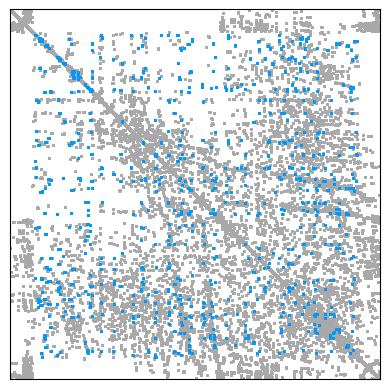

In [18]:

import matplotlib.pyplot as plt

ax = plt.axes()
plt.spy(
    sparsity_pattern_mesh.toarray(),
    markersize=1,
    color="darkgray",
    markeredgecolor="darkgray",
)
plt.spy(
    sparsity_pattern.toarray() - sparsity_pattern_mesh.toarray(),
    markersize=1,
    markeredgecolor="#009AF9",
)


ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [19]:
# [Collapse: code] Newton-Solver with sparse solver

def newton_krylov_solver(
    u,
    fext,
    lifter_plate: lifter.Lifter,
):
    fint = gradient(u, lifter_plate)
    iiter = 0
    norm_res = 1.0
    tol = 1e-8
    max_iter = 80
    while norm_res > tol and iiter < max_iter:
        residual = fext - fint
        A = hessian_fn(u, lifter_plate)
        du = jax.experimental.sparse.linalg.spsolve(
            A.data, A.indices, A.indptr, residual
        )
        u = u.at[:].add(du)

        fint = gradient(u, lifter_plate)
        residual = fext - fint
        norm_res = jnp.linalg.norm(residual)

        print(f"  Residual: {norm_res:.2e}")
        iiter += 1
    return u, norm_res

In [20]:
# [output: hide]

u_prev = jnp.zeros(lifter_plate.size_reduced)
fext = jnp.zeros(lifter_plate.size_reduced)


n_steps = 50
applied_displacement = height * 0.2 / n_steps

u_sol_per_step = []

for i in range(n_steps):
    lifter_plate = lifter_plate.at["top_disp"].set((i + 1) * applied_displacement)

    u_new, rnorm = newton_krylov_solver(u_prev, fext, lifter_plate=lifter_plate)

    u_prev = u_new
    u_full = lifter_plate.lift_from_zeros(u_prev)
    u_sol_per_step.append(u_full)

    print(f"Iteration {i}: Residual Norm = {rnorm:.4e}")

  Residual: 2.77e-01
  Residual: 2.49e-02
  Residual: 2.63e-04
  Residual: 4.45e-08
  Residual: 4.74e-15
Iteration 0: Residual Norm = 4.7447e-15
  Residual: 2.75e-01
  Residual: 2.46e-02
  Residual: 2.57e-04
  Residual: 4.21e-08
  Residual: 4.71e-15
Iteration 1: Residual Norm = 4.7133e-15
  Residual: 2.73e-01
  Residual: 2.43e-02
  Residual: 2.52e-04
  Residual: 3.98e-08
  Residual: 4.69e-15
Iteration 2: Residual Norm = 4.6920e-15
  Residual: 2.71e-01
  Residual: 2.41e-02
  Residual: 2.46e-04
  Residual: 3.77e-08
  Residual: 4.77e-15
Iteration 3: Residual Norm = 4.7739e-15
  Residual: 2.69e-01
  Residual: 2.38e-02
  Residual: 2.41e-04
  Residual: 3.58e-08
  Residual: 4.89e-15
Iteration 4: Residual Norm = 4.8948e-15
  Residual: 2.67e-01
  Residual: 2.35e-02
  Residual: 2.36e-04
  Residual: 3.40e-08
  Residual: 5.13e-15
Iteration 5: Residual Norm = 5.1254e-15
  Residual: 2.66e-01
  Residual: 2.33e-02
  Residual: 2.31e-04
  Residual: 3.24e-08
  Residual: 5.24e-15
Iteration 6: Residual Nor

## Visualization

We now visualize the deformation of the bulk material and the embedded fibres.

In [21]:
# [collapse: code] Post-processing and Visualization

import pyvista as pv


def set_size(fraction=1, height_ratio="golden", width="two-column", subplots=(1, 1)):
    if width == "two-column":
        width_pt = 180  # mm
    elif width == "one-column":
        width_pt = 90  # mm
    else:
        width_pt = width

    if height_ratio == "golden":
        ratio_pt = (np.sqrt(5) - 1.0) / 2.0
    else:
        ratio_pt = height_ratio

    fig_width_pt = width_pt * fraction
    inches_per_pt = 1.0 / 25.4
    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = fig_width_in * ratio_pt * (subplots[0] / subplots[1])
    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim


def get_pv_grid(mesh: Mesh) -> pv.UnstructuredGrid:
    """Convert Tatva mesh to PyVista UnstructuredGrid."""
    if mesh.coords.shape[1] == 2:
        pv_points = np.hstack((mesh.coords, np.zeros(shape=(mesh.coords.shape[0], 1))))
    else:
        pv_points = np.array(mesh.coords)
    cells = np.hstack(
        [
            np.full((mesh.elements.shape[0], 1), 3, dtype=np.int64),
            np.array(mesh.elements, dtype=np.int64),
        ]
    )
    grid = pv.UnstructuredGrid(
        cells, np.full(mesh.elements.shape[0], pv.CellType.TRIANGLE), pv_points
    )
    return grid


def find_domain_boundary(elements):
    # 1. Get all edges (3 per triangle)
    edges = np.concatenate(
        [elements[:, [0, 1]], elements[:, [1, 2]], elements[:, [2, 0]]], axis=0
    )

    # 2. Sort node IDs within each edge to handle directionality
    edges_sorted = np.sort(edges, axis=1)

    # 3. Find unique edges and their counts
    unique_edges, indices, counts = np.unique(
        edges_sorted, axis=0, return_index=True, return_counts=True
    )

    # 4. Boundary edges are those that appear only once
    boundary_edges = edges[indices[counts == 1]]

    return boundary_edges


def get_pv_line_grid(mesh: Mesh) -> pv.PolyData:
    """Convert a Line2 (segment) Tatva mesh to a PyVista PolyData of lines."""
    coords = np.asarray(mesh.coords)
    if coords.shape[1] == 2:
        pv_points = np.hstack((coords, np.zeros((coords.shape[0], 1))))
    else:
        pv_points = coords
    elems = np.asarray(mesh.elements, dtype=np.int64)
    # VTK line connectivity: [n_points_in_cell, id0, id1, ...] per cell
    lines = np.hstack([np.full((elems.shape[0], 1), 2, dtype=np.int64), elems])
    return pv.PolyData(pv_points, lines=lines)


def _pad3(u: Array) -> np.ndarray:
    """Pad a 2D nodal (n, 2) field to (n, 3) so it can warp PyVista points."""
    u = np.asarray(u)
    return np.hstack([u, np.zeros((u.shape[0], 1))])


def _neo_hookean_energy(F: Array) -> Array:
    """Scalar strain-energy density for a single 2x2 deformation gradient."""
    C = F.T @ F
    I1 = jnp.trace(C)
    J = jnp.linalg.det(F)
    return (
        0.5 * mat.mu * (I1 - 2 - 2 * jnp.log(J)) + (mat.lmbda / 2) * (jnp.log(J)) ** 2
    )


@autovmap(F=2)
def von_mises_from_F(F: Array) -> Array:
    """In-plane von Mises stress from the Cauchy stress sigma = J^-1 P F^T."""
    P = jax.grad(_neo_hookean_energy)(F)  # 1st Piola-Kirchhoff (2, 2)
    J = jnp.linalg.det(F)
    sigma = (P @ F.T) / J  # Cauchy stress (2, 2)
    sxx, syy, sxy = sigma[0, 0], sigma[1, 1], sigma[0, 1]
    return jnp.sqrt(sxx**2 - sxx * syy + syy**2 + 3 * sxy**2)


def plate_von_mises(u2d: Array) -> np.ndarray:
    """Per-element (per quadrature point) von Mises stress for a nodal field."""
    grad_u = op_plate.grad(u2d)
    F = compute_deformation_gradient(grad_u)
    return np.asarray(von_mises_from_F(F)).reshape(-1)


def animate_deformation(
    save_gif: str | None = None,
    plate_cmap: str = "viridis",
    fiber_cmap: str = "magma",
):
    """Step through ``u_sol_per_step``, warping the plate and fibers.

    With ``save_gif`` a GIF is written; otherwise an interactive window opens
    with a slider to scrub through the load steps. Colour limits are fixed to
    the global range so steps are directly comparable.
    """
    plate_grid = get_pv_grid(plate_mesh)
    fiber_grid = get_pv_line_grid(fiber_mesh)
    plate_pts0 = plate_grid.points.copy()
    fiber_pts0 = fiber_grid.points.copy()

    # lift_from_zeros returns a flat DOF vector; reshape to (n_nodes, 2).
    u2d_steps = [
        jnp.asarray(u).reshape(plate_mesh.coords.shape[0], 2) for u in u_sol_per_step
    ]

    # Precompute per-step warp fields and scalars.
    plate_disp = [_pad3(u) for u in u2d_steps]
    plate_vm = [plate_von_mises(u) for u in u2d_steps]  # per-element von Mises
    fiber_disp = [_pad3(interpolater(u)) for u in u2d_steps]
    fiber_strain = [
        np.asarray(op_line.grad(interpolater(u)).flatten()) for u in u2d_steps
    ]

    plate_clim = [0.0, float(max(s.max() for s in plate_vm))]
    fiber_clim = [
        float(min(s.min() for s in fiber_strain)),
        float(max(s.max() for s in fiber_strain)),
    ]

    def set_step(i):
        i = int(round(i))
        plate_grid.points = plate_pts0 + plate_disp[i]
        plate_grid["von Mises"] = plate_vm[i]
        fiber_grid.points = fiber_pts0 + fiber_disp[i]
        fiber_grid["strain"] = fiber_strain[i]

    pl = pv.Plotter(off_screen=save_gif is not None)
    set_step(0)
    pl.add_mesh(
        plate_grid,
        scalars="von Mises",
        cmap=plate_cmap,
        clim=plate_clim,
        show_edges=False,
        edge_color="gray",
        line_width=0.0,
        scalar_bar_args={
            "title": "von Mises",
            "vertical": False,
            "position_x": 0.05,
            "position_y": 0.05,
            "width": 0.4,
            "height": 0.05,
        },
    )
    pl.add_mesh(
        fiber_grid,
        scalars="strain",
        cmap=fiber_cmap,
        clim=fiber_clim,
        line_width=6,
        render_lines_as_tubes=True,
        scalar_bar_args={
            "title": "fiber strain",
            "vertical": False,
            "position_x": 0.55,
            "position_y": 0.05,
            "width": 0.4,
            "height": 0.05,
        },
    )
    pl.view_xy()
    pl.enable_parallel_projection()

    n = len(u_sol_per_step)
    if save_gif is not None:
        pl.open_gif(save_gif)
        for i in range(n):
            set_step(i)
            pl.write_frame()
        pl.close()
    else:
        pl.add_slider_widget(
            set_step,
            [0, n - 1],
            value=0,
            title="load step",
            fmt="%.0f",
        )
        pl.show()
    return pl

In [23]:
animate_deformation(
    save_gif="soft_hydrogel.gif", plate_cmap="Spectral", fiber_cmap="coolwarm"
)

![Deformation of plate embedded with springs](../assets/images/soft_hydrogel.gif)